In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
pd.set_option('display.max_columns', None)
import copy
import os
import sklearn
from sklearn.model_selection import train_test_split
from pcntoolkit import NormData
import warnings
import logging
import pcntoolkit.util.output
from PIL import Image
from pcntoolkit import (
    BLR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)


sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(True)

pd.set_option('display.max_rows', 100)
#this code was needed to run the code below without errors
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    # Legacy Python that doesn't verify HTTPS certificates by default
    pass
else:
    # Handle target environment that doesn't support HTTPS verification
    ssl._create_default_https_context = _create_unverified_https_context

print('test')

test


In [7]:
path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/final_data"

euler_nr = pd.read_csv(os.path.join(path, "euler_nr_data.csv"))
datatable = pd.read_csv(os.path.join(path, "Final_data.csv"))

euler_nr = euler_nr[['SubjectID', 'avg_euler_centered_neg_sqrt']].copy()
df_ukb = datatable.merge(euler_nr, how="right")
df_ukb = df_ukb.iloc[:, 1:]
df_ukb = df_ukb.dropna(axis=1)

#these cols had only zeros (left-vessel had 0s in some cases but not all --> may fit a separate model for this)
df_ukb["avg_euler_centered_neg_sqrt"] = df_ukb["avg_euler_centered_neg_sqrt"].astype(float)
df_ukb = df_ukb[df_ukb["avg_euler_centered_neg_sqrt"] < 10.0]

df_ukb = df_ukb.drop(columns=['SubjectID','Year_initial_scan','Birthyear','avg_euler_centered_neg_sqrt','5th-Ventricle','Left-WM-hypointensities','Left-non-WM-hypointensities','Left-vessel','Left-WM-hypointensities','Left-non-WM-hypointensities','Right-WM-hypointensities','Right-non-WM-hypointensities', 'non-WM-hypointensities'])
df_ukb["Dataset"]= "UKB"
first_cols = ["Age", "Sex", "Site", "Dataset"]
other_cols = df_ukb.columns.difference(first_cols, sort=False)
df_ukb = df_ukb[first_cols + list(other_cols)]

In [8]:
df_o3 = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/csv_files/Oasis3_data.csv")

#these cols had only zeros (left-vessel had 0s in some cases but not all --> may fit a separate model for this)
df_o3 = df_o3.drop(columns=['SubjectID','5th-Ventricle','Left-WM-hypointensities','Left-non-WM-hypointensities','Left-vessel','Left-WM-hypointensities','Left-non-WM-hypointensities','Right-WM-hypointensities','Right-non-WM-hypointensities'])

pd.set_option('display.max_columns', None)
df_o3 = df_o3.iloc[:,1:]

#split datasets into alzheimer vs healthy controls
alzheimer_df = df_o3[df_o3["Diagnosis"] >= 1.0]
healthy_controls_o3 = df_o3[df_o3["Diagnosis"] == 0.0]

#remove diagnosis from the Healthy control dataframe
healthy_controls_o3 = healthy_controls_o3.drop(columns=['Diagnosis'])

#order the HC the same way as the UKB dataset
ordering_ukb = list(df_ukb.columns)
healthy_controls_o3["Dataset"] = "OASIS3"
healthy_controls_o3 = healthy_controls_o3[ordering_ukb]
df_o3["Dataset"] = "OASIS3"

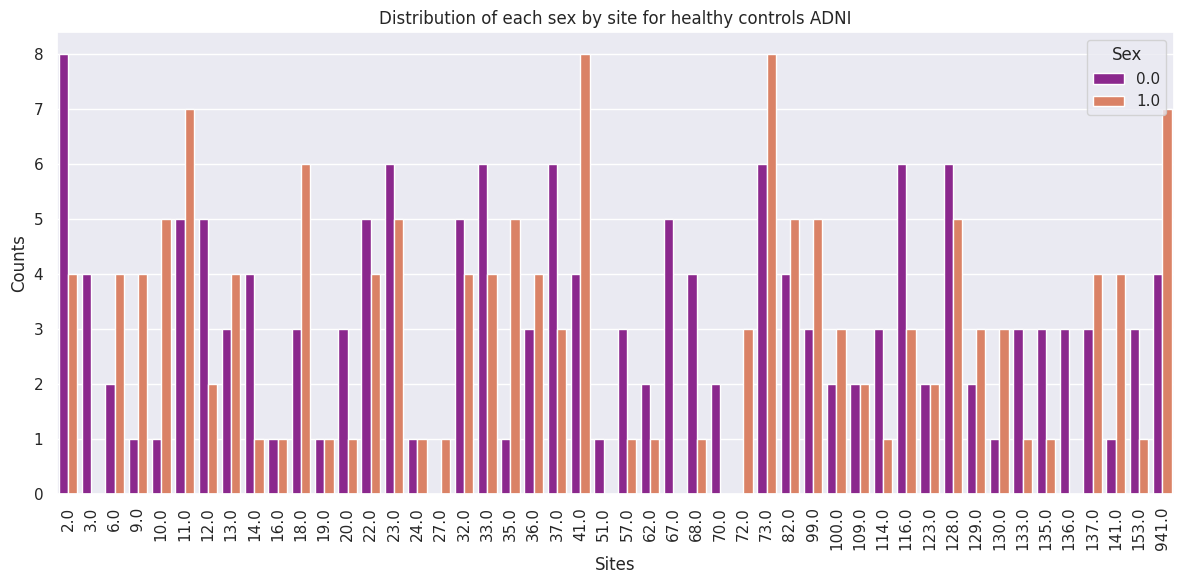

In [31]:
df_adni = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/data_prep/ADNI_data.csv")
df_adni = df_adni.iloc[:,1:]
df_adni.replace(to_replace=['F'], value=0.0, inplace=True)
df_adni.replace(to_replace=['M'], value=1.0, inplace=True)
df_adni = df_adni[df_adni["Sex"] != "X"]
df_adni["Age"] = df_adni["Age"].round()
healthy_controls_adni = df_adni[df_adni["Group"] == "CN"]
healthy_controls_adni.drop(columns=["Group"])
healthy_controls_adni["Dataset"] = "ADNI"
healthy_controls_adni = healthy_controls_adni[ordering_ukb]
df_adni["Dataset"] = "ADNI"

grouped_data = healthy_controls_adni.groupby(['Site', 'Sex']).size().reset_index(name='Count')
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_data, x='Site', y='Count', hue='Sex',palette='plasma')
plt.title('Distribution of each sex by site for healthy controls ADNI')
plt.xlabel('Sites')
plt.ylabel('Counts')
plt.xticks(rotation=90)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()


In [23]:
df_o3["Age"].describe()

# adni_path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/data_prep/"
# adni_data = pd.read_csv(os.path.join(adni_path, "ADNI_data.csv"))
# adni_data = adni_data.iloc[:,1:]
# adni_data["Sex"] = adni_data["Sex"].replace({"F":0, "M":1})
# adni_data = adni_data.rename(columns={"Group":"Diagnosis"})
# adni_data = adni_data[adni_data["Sex"] != "X"]
# adni_data = adni_data.drop(columns=["participant_id"])
# adni_data["Dataset"] = "ADNI"
# full_data = pd.concat([adni_data, df_o3, df_ukb], axis=0)
# full_data["Age"].describe()

count    1893.000000
mean       69.767565
std         9.387414
min        43.000000
25%        64.000000
50%        70.000000
75%        76.000000
max        97.000000
Name: Age, dtype: float64

In [34]:
data_df = pd.concat([df_ukb, healthy_controls_o3, healthy_controls_adni], axis=0)

# data_df = data_df[data_df["Site"] != 27.0]
# data_df = data_df[data_df["Site"] != 51.0]
# data_df = data_df[data_df["Age"] != 95.0]
# data_df = data_df[data_df["Age"] != 97.0]


In [32]:
data_df = pd.concat([df_ukb, healthy_controls_o3, healthy_controls_adni], axis=0)

#removing sites with only 1 participant per sex [train_test_split error]
data_df = data_df[~data_df["Site"].isin([9.0, 10.0, 14.0, 16.0, 19.0, 20.0, 24.0, 27.0, 35.0, 51.0, 57.0, 68.0, 62.0, 67.0, 70.0, 114.0, 130.0, 133.0, 135.0, 136.0, 141.0, 153.0])]

#removing these ages because they had unique site & age combinations which could not be split 
data_df = data_df[data_df["Age"] != 96.0]
data_df = data_df[data_df["Age"] != 91.0]
data_df = data_df[data_df["Age"] != 95.0]
data_df = data_df[data_df["Age"] != 97.0]

#try some to create some variables that are not informative 
data_df["Covariates"] = 10.0
data_df["Batcheffects_1"] = 10.0
data_df["Batcheffects_2"] = 10.0

data = data_df
covariates = ["Covariates"]
batch_effects = ["Batcheffects_1", "Batcheffects_2"]

data_df = data_df.drop(columns=['Age','Sex','Site','Dataset', 'Covariates', 'Batcheffects_1', 'Batcheffects_2'])
columns = list(data_df.columns)

response_vars = columns

# create a NormData object
norm_data = NormData.from_dataframe(
    name="Final_BLR_uncorrected", dataframe=data, covariates=covariates, batch_effects=batch_effects, response_vars=response_vars
)
norm_data.coords

train_plt, test_plt = train_test_split(data, test_size=0.2, random_state=42)
train, test = norm_data.train_test_split([0.8, 0.2])


Process: 506438 - 2026-04-16 10:56:07 - Dataset "Final_BLR_uncorrected" created.
    - 35378 observations
    - 35378 unique subjects
    - 1 covariates
    - 103 response variables
    - 2 batch effects:
    	Batcheffects_1 (1)
	Batcheffects_2 (1)
    


In [33]:
template_blr = BLR(
    name="BLR_uncorrected_all_data",
    basis_function_mean=BsplineBasisFunction(
        degree=3, nknots=5 
    ),  # We use a B-spline basis expansion for the mean, so the predicted mean is a smooth function of the covariates
    fixed_effect=True,  # By setting fixed_effect=True, we \model offsets in the mean for each individual batch effect,
    heteroskedastic=True, #maybe True # We want the variance to be a function of the covariates too
    warp_name="warpsinharcsinh",  # We configure a sinh-arcsinh warp, so we can model flexible non-gaussian distributions
)

model = NormativeModel(
    # The regression model to use for the normative model.
    template_regression_model=template_blr,
    # Whether to save the model after fitting.
    savemodel=True,
    # Whether to evaluate the model after fitting.
    evaluate_model=True,
    # Whether to save the results after evaluation.
    saveresults=True,
    # Whether to save the plots after fitting.
    saveplots=True,
    # The directory to save the model, results, and plots.
    save_dir="/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/BLR/Final_BLRs/Final_BLR_uncorrected_results",
    # The scaler to use for the input data. Can be either one of "standardize", "minmax", "robminmax", "none"
    inscaler="standardize",
    # The scaler to use for the output data. Can be either one of "standardize", "minmax", "robminmax", "none"
    outscaler="standardize",
)

model.fit_predict(train, test)

Process: 506438 - 2026-04-16 10:56:11 - Fitting models on 103 response variables.
Process: 506438 - 2026-04-16 10:56:11 - Fitting model for lh_G_front_inf-Triangul_thickness.


/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/pcntoolkit/math_functions/scaler.py:272: RuntimeWarning: invalid value encountered in divide
  return (X - self.m) / self.s


ValueError: Array must not contain infs or nans.